# Experiment Comparison: Decoding Strategies & Config Variations

This notebook runs 2-3 experiments with different configurations (decoding strategy, sample size) on zero-shot BLIP and logs each to MLflow for comparison.

In [27]:
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import pandas as pd
import os
import mlflow
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("flickr8k-image-captioning")

print("✅ Model loaded, MLflow connected")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

✅ Model loaded, MLflow connected


In [28]:
df = pd.read_csv("../data/captions.txt", sep="|")
df.columns = df.columns.str.strip()

image_folder = "../data/Images"

 
eval_images = df['image_name'].unique()[:50]
print(f"Evaluation set size: {len(eval_images)}")

Evaluation set size: 50


In [29]:
smoothie = SmoothingFunction().method4
rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

def run_experiment(run_name, decoding_strategy="greedy", num_beams=1, max_tokens=30):
    """
    decoding_strategy: 'greedy' or 'beam'
    num_beams: beam search ke liye (greedy ke liye 1 rakhein)
    """
    results = []
    
    for img_name in eval_images:
        img_path = os.path.join(image_folder, img_name)
        raw_image = Image.open(img_path).convert("RGB")
        inputs = processor(raw_image, return_tensors="pt").to(device)
        
        if decoding_strategy == "greedy":
            out = model.generate(**inputs, max_new_tokens=max_tokens, num_beams=1)
        else:  # beam search
            out = model.generate(**inputs, max_new_tokens=max_tokens, num_beams=num_beams)
        
        generated = processor.decode(out[0], skip_special_tokens=True)
        
        references = df[df['image_name'] == img_name]['caption_text'].astype(str).tolist()
        ref_tokens = [r.lower().split() for r in references]
        gen_tokens = generated.lower().split()
        
        bleu = sentence_bleu(ref_tokens, gen_tokens, smoothing_function=smoothie)
        meteor = meteor_score([r.lower().split() for r in references], gen_tokens)
        rouge_scores = [rouge.score(r.lower(), generated.lower())['rougeL'].fmeasure for r in references]
        best_rouge = max(rouge_scores)
        
        results.append({"image": img_name, "generated": generated, 
                         "bleu": bleu, "meteor": meteor, "rougeL": best_rouge})
    
    results_df = pd.DataFrame(results)
    avg_bleu = results_df['bleu'].mean()
    avg_meteor = results_df['meteor'].mean()
    avg_rouge = results_df['rougeL'].mean()
    
    # MLflow mein log karein
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("decoding_strategy", decoding_strategy)
        mlflow.log_param("num_beams", num_beams)
        mlflow.log_param("eval_size", len(eval_images))
        mlflow.log_param("max_tokens", max_tokens)
        
        mlflow.log_metric("avg_bleu", avg_bleu)
        mlflow.log_metric("avg_meteor", avg_meteor)
        mlflow.log_metric("avg_rougeL", avg_rouge)
    
    print(f"✅ {run_name} done — BLEU: {avg_bleu:.4f}, METEOR: {avg_meteor:.4f}, ROUGE-L: {avg_rouge:.4f}")
    return results_df, avg_bleu, avg_meteor, avg_rouge

In [30]:
results_1, bleu_1, meteor_1, rouge_1 = run_experiment(
    run_name="exp1_greedy_decoding",
    decoding_strategy="greedy"
)

🏃 View run exp1_greedy_decoding at: http://localhost:5000/#/experiments/1/runs/e614cb5f17d64f5ba0ba001e2c34d440
🧪 View experiment at: http://localhost:5000/#/experiments/1
✅ exp1_greedy_decoding done — BLEU: 0.2025, METEOR: 0.3882, ROUGE-L: 0.5277


In [31]:
results_2, bleu_2, meteor_2, rouge_2 = run_experiment(
    run_name="exp2_beam_search_3",
    decoding_strategy="beam",
    num_beams=3
)

🏃 View run exp2_beam_search_3 at: http://localhost:5000/#/experiments/1/runs/6af38017c9424d188dfd891cde453598
🧪 View experiment at: http://localhost:5000/#/experiments/1
✅ exp2_beam_search_3 done — BLEU: 0.2229, METEOR: 0.3804, ROUGE-L: 0.5082


In [32]:
results_3, bleu_3, meteor_3, rouge_3 = run_experiment(
    run_name="exp3_beam_search_5",
    decoding_strategy="beam",
    num_beams=5
)

🏃 View run exp3_beam_search_5 at: http://localhost:5000/#/experiments/1/runs/3489ed3c13384745a37b6f91afa196c0
🧪 View experiment at: http://localhost:5000/#/experiments/1
✅ exp3_beam_search_5 done — BLEU: 0.2088, METEOR: 0.3870, ROUGE-L: 0.5048


In [33]:
comparison_df = pd.DataFrame({
    "Experiment": ["Greedy Decoding", "Beam Search (3)", "Beam Search (5)"],
    "BLEU": [bleu_1, bleu_2, bleu_3],
    "METEOR": [meteor_1, meteor_2, meteor_3],
    "ROUGE-L": [rouge_1, rouge_2, rouge_3]
})

comparison_df

,Experiment,BLEU,METEOR,ROUGE-L
0,Greedy Decoding,0.202461,0.388157,0.527728
1,Beam Search (3),0.222875,0.380398,0.508248
2,Beam Search (5),0.208757,0.387005,0.504850


In [34]:
comparison_df.to_csv("../data/processed/day4_experiment_comparison.csv", index=False)
print("✅ Comparison table saved")

✅ Comparison table saved


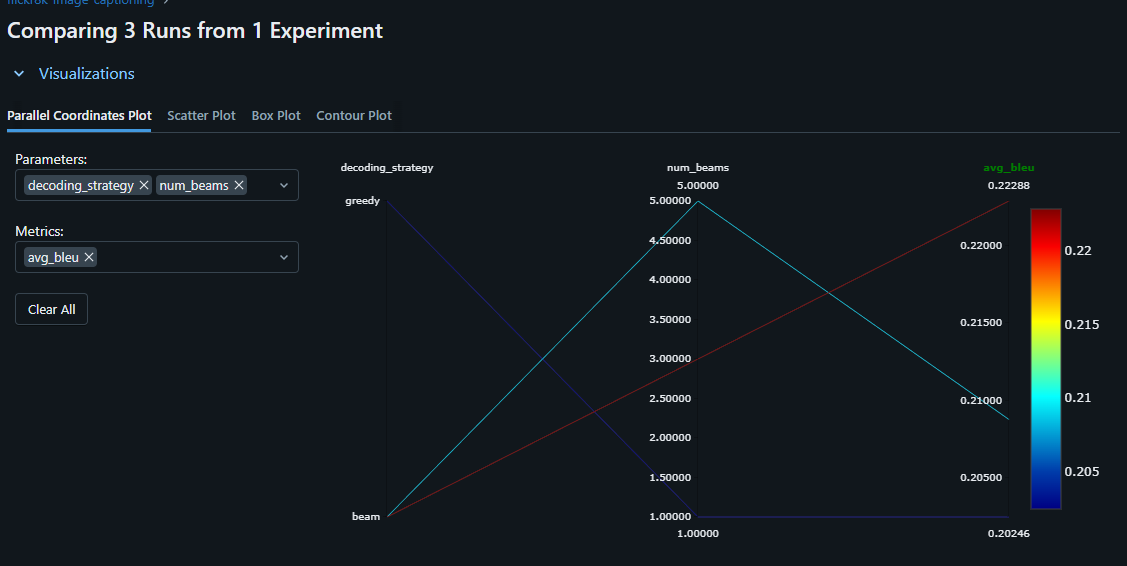